# Pregunta 1

Aprendiendo de lo que me demoré en hacer la 3 comenzaré a guiarme por las preguntas guiadas, por lo que primero que haré es pasar funciones disponibles en el canva del curso con las transformaciones necesarias entre los distintos espacios de color

In [1]:
%pip install opencv-python matplotlib numpy
import cv2
import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## HSV Y RGB
Para las funciones de transformación reutilizaré las que ya estan disponibles en el canva del curso

In [2]:
def rgb_to_hsv(img: np.ndarray) -> np.ndarray:

  img = img.astype(np.float64)
  img = img/ 255.0

  R = img[:, :, 0]
  G = img[:, :, 1]
  B = img[:, :, 2]

  #Nuevamente se define un epsilon pensando en caso borde de imagen negra
  epsilon = 1e-10

  # Se definen los C y delta
  C_max = np.maximum(np.maximum(R, G), B)
  C_min = np.minimum(np.minimum(R, G), B)
  delta = C_max - C_min

  # V es directamente el valor máximo
  V = C_max

  # S establece la condicion de saturacion
  S = np.where(C_max > epsilon, delta / (V + epsilon), 0.0)

  # Para el cálculo de H se define una matriz a "rellenar"
  H = np.zeros_like(V)

  # De acuerdo con el canal dominante por pixel creamos mascaras booleanas

  mask_r = (C_max == R) * (delta > epsilon)
  mask_g = (C_max == G) * (delta > epsilon)
  mask_b = (C_max == B) * (delta > epsilon)

  # Se define la fórmula correspondiente por color dominante

  H[mask_r] = 60.0 * (((G[mask_r] - B[mask_r]) / delta[mask_r]) % 6)
  H[mask_g] = 60.0 * (((B[mask_g] - R[mask_g]) / delta[mask_g]) + 2)
  H[mask_b]= 60.0 * (((R[mask_b] - G[mask_b]) / delta[mask_b]) + 4)

  #Si algún grado quedo menor a 0 sumamos 360°

  H = np.where(H < 0, H + 360.0, H)

  #Para zonas grises
  H = np.where(delta < epsilon, 0.0, H)

  hsv_img = np.stack([H, S, V], axis=-1)
  return hsv_img


def plot_hsv(hsv_img: np.ndarray):

  H = hsv_img[:, :, 0]
  S = hsv_img[:, :, 1]
  V = hsv_img[:, :, 2]

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))

  canales = [
      (H, "Hue (H)", "hsv", 0, 360),
      (S, "Saturation (S)", "Reds", 0, 1),
      (V, "Value (V)", "gray", 0, 1)
  ]

  for ax, (canal, titulo, cmap, vmin, vmax) in zip(axes, canales):
    im = ax.imshow(canal, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(titulo)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

  fig.tight_layout()

def hsv_to_rgb(hsv_img: np.ndarray) -> np.ndarray:

  H = hsv_img[:, :, 0] % 360.0
  S = np.clip(hsv_img[:, :, 1], 0.0, 1.0)
  V = np.clip(hsv_img[:, :, 2], 0.0, 1.0)

  C = V * S
  Hp = H / 60.0
  X = C * (1 - np.abs(Hp % 2 - 1))
  m = V - C

  Rp = np.zeros_like(V)
  Gp = np.zeros_like(V)
  Bp = np.zeros_like(V)

  mask0 = (Hp >= 0) & (Hp < 1)
  mask1 = (Hp >= 1) & (Hp < 2)
  mask2 = (Hp >= 2) & (Hp < 3)
  mask3 = (Hp >= 3) & (Hp < 4)
  mask4 = (Hp >= 4) & (Hp < 5)
  mask5 = (Hp >= 5) & (Hp <= 6)

  Rp[mask0], Gp[mask0], Bp[mask0] = C[mask0], X[mask0], 0.0
  Rp[mask1], Gp[mask1], Bp[mask1] = X[mask1], C[mask1], 0.0
  Rp[mask2], Gp[mask2], Bp[mask2] = 0.0, C[mask2], X[mask2]
  Rp[mask3], Gp[mask3], Bp[mask3] = 0.0, X[mask3], C[mask3]
  Rp[mask4], Gp[mask4], Bp[mask4] = X[mask4], 0.0, C[mask4]
  Rp[mask5], Gp[mask5], Bp[mask5] = C[mask5], 0.0, X[mask5]

  rgb_img = np.clip(np.stack([Rp + m, Gp + m, Bp + m], axis=-1), 0.0, 1.0)
  return rgb_img
  

## XYZ Y RGB

In [3]:
def _gamma_to_linear(c: np.ndarray, gamma: float = 2.2) -> np.ndarray:
  return c ** gamma

def rgb_to_xyz(img: np.ndarray) -> np.ndarray:

  img = img.astype(np.float64)
  img = img / 255.0

  matrix = np.array([
      [0.490, 0.310, 0.200],
      [0.177, 0.813, 0.011],
      [.000, .010, 0.990],
  ])

  rgb_linear = _gamma_to_linear(img)

  xyz = rgb_linear @ matrix.T

  return xyz


def xyz_to_rgb(xyz_img: np.ndarray) -> np.ndarray:

    matrix = np.array([
        [0.490, 0.310, 0.200],
        [0.177, 0.813, 0.011],
        [.000, .010, 0.990],
    ])

    inv = np.linalg.inv(matrix)

    rgb_linear = xyz_img @ inv.T
    rgb_linear = np.clip(rgb_linear, 0.0, 1.0)

    rgb = rgb_linear ** (1.0 / 2.2)

    return np.clip(rgb, 0.0, 1.0)



## LAB Y RGB Y XYZ Y LCH

In [5]:

def rgb_to_lab(img: np.ndarray) -> np.ndarray:

  _X_n = 1.0
  _Y_n = 1.0
  _Z_n = 1.0

  xyz = rgb_to_xyz(img)

  xr = xyz[:, :, 0] / _X_n
  yr = xyz[:, :, 1] / _Y_n
  zr = xyz[:, :, 2] / _Z_n

  delta = 6.0 / 29.0

  def f(t):
    return np.where(t > delta ** 3, np.cbrt(t), t / (3 * delta ** 2) + 4.0 / 29.0)

  fx, fy, fz = f(xr), f(yr), f(zr)

  L = 116.0 * fy - 16.0
  a = 500.0 * (fx - fy)
  b = 200.0 * (fy - fz)

  lab_img = np.stack([L, a, b], axis=-1)
  return lab_img


def lab_to_xyz(lab_img: np.ndarray) -> np.ndarray:

    _X_n = 1.0
    _Y_n= 1.0
    _Z_n = 1.0

    L = lab_img[:, :, 0]
    a = lab_img[:, :, 1]
    b = lab_img[:, :, 2]

    fy = (L + 16.0) / 116.0
    fx = fy + a / 500.0
    fz = fy - b / 200.0

    delta = 6.0 / 29.0

    def f_inv(f):
        return np.where(f > delta, f ** 3, 3 * delta ** 2 * (f - 4.0 / 29.0))

    X = f_inv(fx) * _X_n
    Y = f_inv(fy) * _Y_n
    Z = f_inv(fz) * _Z_n

    return np.stack([X, Y, Z], axis=-1)


def lab_to_rgb(lab_img: np.ndarray) -> np.ndarray:
  return xyz_to_rgb(lab_to_xyz(lab_img))

def rgb_to_lch(img: np.ndarray) -> np.ndarray:

    lab = rgb_to_lab(img)

    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    C = np.sqrt(a ** 2 + b ** 2)
    h = np.degrees(np.arctan2(b, a))
    h = np.where(h < 0, h + 360.0, h)

    lch_img = np.stack([L, C, h], axis=-1)
    return lch_img


def lch_to_lab(lch_img: np.ndarray) -> np.ndarray:
  L = lch_img[:, :, 0]
  C = lch_img[:, :, 1]
  h = np.radians(lch_img[:, :, 2])

  a = C * np.cos(h)
  b = C * np.sin(h)

  return np.stack([L, a, b], axis=-1)


def lch_to_rgb(lch_img: np.ndarray) -> np.ndarray:
  return lab_to_rgb(lch_to_lab(lch_img))

## Periodicidad del tono

Busco que mi función retorne un valor m que se aplicará para escalar la saturación de un color en específico

In [11]:
def interpolacion(hue, puntos):
    hue = hue%360 #la periodicidad de 360
    puntos.sort() #esto me ayuda a encontrar específicamente el inicio y el final, se asume el peor caso que es el cruce por 0
    fin = puntos[0]
    inicio = puntos[-1]
    #ahora lo que busco es  cuales son los dos puntos de control más cercanos al color actual (para encerrarlo)
    for i in puntos:
        if i[0] <= hue: 
            inicio = i
        if i[0] >= hue:
            fin = i
            break
    #Ahora que ya definí los puntos puedo calcular la interpolación como tal
    distancia = (fin[0] - inicio[0]) % 360 #esta distancia está en grados
    if distancia == 0: #esto es cuando los puntos están en la misma posición, así que lo devuelve directamente
        return inicio[1]
    m =  inicio[1] + (((hue - inicio[0]) % 360) / distancia) * (fin[1] - inicio[1]) #si no, se calcula como siempre 
    return m

## Función gm

Para la función gm decidi irme a algo sencillo, donde la saturación de salida va a ser la multiplicación de la saturación actual y m (la salida de mi función de interpolación) que es el factor de aplificación o atenuación.

In [20]:
def gm(s, m):
    #esta función amplifica con un m mayor a 1, con m igual a 1 no cambia y con m menor a 1 pero mayor a 0 reduce, si  es igual a 0 queda completamente gris
    sout = s*m
    sout = np.maximum(sout, 0)
    return sout

## LUTs
Recomendación que se hizo en clases para reducr tiempo de ejecución

In [ ]:
def LUTs(puntos, grados):
    lut = [] #acá guardo las respuestas precalculadas
    for i in range(grados):
        hue = i * 360 / grados #acá calcula el hue en el circulo
        valor = interpolacion(hue, puntos) #llama a mi función de interpolación
        lut.append(valor) #se agrega el valor a la lista
    return np.array(lut) #La lista queda como un arreglo que se puede aplicar directamente a la imagen

## ColorSaturación

In [43]:
def ColorSaturacion(imagen, salida, puntos, modo):
    # la lut se arma con los 360 grados para abarcar todos los tonos
    lut = LUTs(puntos, 360) 
    largo = len(lut)

    # voy a decir que 1 va a ser HS 
    if modo == 1:
        hsv = rgb_to_hsv(imagen)
        H = hsv[:, :, 0]
        S = hsv[:, :, 1]
        # pasa del hue en grados a un indice para buscar en la LUT
        indice = np.round(H / 360 * largo).astype(int) % largo
        m = lut[indice]
        SatNueva = gm(S, m)
        SatNueva = np.clip(SatNueva, 0, 1) #esto es para que no sea mayor que 1, porque se supone que está normalizado y no tendria sentido que fuera más de 1

        #no me interesa cambiar ni H ni V, asi que solo cambio S
        hsv[:, :, 1] = SatNueva
        resultado = hsv_to_rgb(hsv) * 255 #el 255 es para desnormalizar lo que entrega la función

    # acá defino que 2 es LCH -----------------------------------------
    if modo == 2:
        #ee repite el procedimiento pero para lch
        lch = rgb_to_lch(imagen)
        C = lch[:, :, 1]
        H = lch[:, :, 2]

        indice = np.round(H / 360 * largo).astype(int) % largo
        m = lut[indice]

        CNuevo = gm(C, m)

        lch[:, :, 1] = CNuevo
        resultado = lch_to_rgb(lch) * 255 #el 255 es para desnormalizar lo que entrega la función

    # corta el resultado si exccede el 255 para que esté en el rango de 8 bits
    resultado = np.clip(resultado, 0, 255)
    resultado = resultado.astype(np.uint8)

    # lo guardo y el resultado se invierte el orden de canales cv2 necesita BGR
    cv2.imwrite(salida, resultado[:, :, ::-1])
    print(salida )

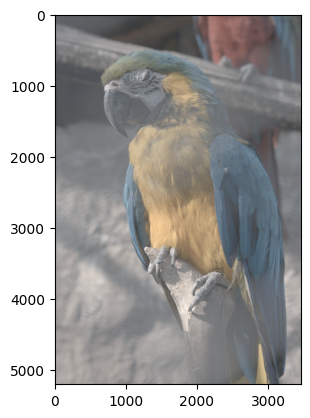

In [33]:
#Primero cargo la imágen para asegurarme que todo esté bien
imagen = cv2.imread('P1_IMG_2402.tif')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
#Ploteo la imágen directamente 
plt.imshow(imagen)

Para la pregunta guiada de elegir un pixel y mostrar sus valores intermedios

In [49]:

puntos = [(0, 1), (120, 5), (240, 0.2)]
fila, columna = 2000, 1200 #elijo un pixel
#tomo sus valores de RGB y los printeo
r = int(imagen[fila, columna, 0])
g = int(imagen[fila, columna, 1])
b = int(imagen[fila, columna, 2])
print(r, g, b)

# imagen de 1x1
pixel = np.array([[[r, g, b]]])

hsv = rgb_to_hsv(pixel)
H = hsv[0, 0, 0]
S = hsv[0, 0, 1]
V = hsv[0, 0, 2]

m = interpolacion(H, puntos)     # el valor interpolado
SatNueva = gm(S, m)               # resultado de gm
SatNueva = np.clip(SatNueva, 0, 1) # mismo recorte que usas en ColorSaturacion

rgb_final = hsv_to_rgb(np.array([[[H, SatNueva, V]]])) * 255

print("Hue:", H)
print("Saturacion original:", S)
print("m(h):", m)
print("Saturacion final", SatNueva)
print("RGB final:", rgb_final[0, 0])

194 176 147
Hue: 37.021276595744695
Saturacion original: 0.2422680412052689
m(h): 2.2340425531914896
Saturacion final 0.54123711333092
RGB final: [194.         153.78723405  89.00000001]


resultadoHS.jpg


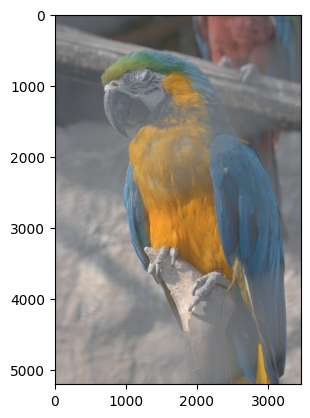

In [ ]:
ColorSaturacion(imagen, 'resultadoHS.jpg', puntos, 1)

resultado = cv2.imread('resultadoHS.jpg')

resultado = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.imshow(resultado)
plt.imshow(resultado)